# Trigonometric Substitution

A guided notebook on integrating expressions that contain **square roots of quadratics**.

This notebook explains:
- when and why to use a trigonometric substitution
- the three standard forms $\sqrt{a^2 - x^2}$, $\sqrt{a^2 + x^2}$, $\sqrt{x^2 - a^2}$
- the **reference triangle** used to substitute back
- worked examples for each case

This notebook follows the same style template as the uploaded guidelines, and builds on the $u$-substitution notebook.

## 1. Introduction

Ordinary $u$-substitution works when the derivative of an inner function already appears in the integrand. But many integrands contain a **square root of a quadratic** — like $\sqrt{a^2 - x^2}$ — where no such factor is present.

For these, we use a **trigonometric substitution**: we replace $x$ with a trig function of a new variable $\theta$, chosen so that a **Pythagorean identity** collapses the square root into a single trig function.

The three identities that make this work are:

$$
1 - \sin^2\theta = \cos^2\theta, \qquad
1 + \tan^2\theta = \sec^2\theta, \qquad
\sec^2\theta - 1 = \tan^2\theta.
$$

## 2. The Three Standard Substitutions

| Expression in integrand | Substitution | $dx$ | Identity used | Simplifies to |
|-------------------------|--------------|------|---------------|----------------|
| $\sqrt{a^2 - x^2}$ | $x = a\sin\theta$ | $a\cos\theta\,d\theta$ | $1 - \sin^2\theta = \cos^2\theta$ | $a\cos\theta$ |
| $\sqrt{a^2 + x^2}$ | $x = a\tan\theta$ | $a\sec^2\theta\,d\theta$ | $1 + \tan^2\theta = \sec^2\theta$ | $a\sec\theta$ |
| $\sqrt{x^2 - a^2}$ | $x = a\sec\theta$ | $a\sec\theta\tan\theta\,d\theta$ | $\sec^2\theta - 1 = \tan^2\theta$ | $a\tan\theta$ |

**The idea in one line:** choose the substitution that turns the quadratic under the root into a perfect square times a single $\cos^2$, $\sec^2$, or $\tan^2$, so the root disappears.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp

x, theta = sp.symbols('x theta', real=True)
a = sp.symbols('a', positive=True)

## 3. The Sine Case: $\sqrt{a^2 - x^2}$

Substitute $x = a\sin\theta$, so $dx = a\cos\theta\,d\theta$. Then

$$
\sqrt{a^2 - x^2} = \sqrt{a^2 - a^2\sin^2\theta} = \sqrt{a^2(1 - \sin^2\theta)} = a\sqrt{\cos^2\theta} = a\cos\theta.
$$

### Worked example

$$
I = \int \frac{1}{\sqrt{9 - x^2}}\,dx.
$$

Here $a = 3$, so $x = 3\sin\theta$, $dx = 3\cos\theta\,d\theta$, and $\sqrt{9 - x^2} = 3\cos\theta$:

$$
I = \int \frac{3\cos\theta}{3\cos\theta}\,d\theta = \int d\theta = \theta + C.
$$

**Substitute back.** From $x = 3\sin\theta$ we get $\theta = \arcsin\!\left(\dfrac{x}{3}\right)$, so

$$
\boxed{\;\int \frac{1}{\sqrt{9 - x^2}}\,dx = \arcsin\!\left(\frac{x}{3}\right) + C\;}
$$

In [2]:
I = sp.integrate(1/sp.sqrt(9 - x**2), x)
print("integral of 1/sqrt(9 - x^2) =", I, "+ C")

# A harder one with the same substitution: area-type integral
J = sp.integrate(sp.sqrt(9 - x**2), x)
print("integral of sqrt(9 - x^2)   =", sp.simplify(J), "+ C")

integral of 1/sqrt(9 - x^2) = asin(x/3) + C
integral of sqrt(9 - x^2)   = x*sqrt(9 - x**2)/2 + 9*asin(x/3)/2 + C


## 4. The Reference Triangle

After integrating in $\theta$, we must return to $x$. The cleanest way is a **right triangle** that encodes the substitution.

For $x = a\sin\theta$ we have $\sin\theta = \dfrac{x}{a} = \dfrac{\text{opposite}}{\text{hypotenuse}}$, so draw a right triangle with **opposite** $= x$, **hypotenuse** $= a$, and therefore **adjacent** $= \sqrt{a^2 - x^2}$.

Then every trig function of $\theta$ can be read off directly, e.g. $\cos\theta = \dfrac{\sqrt{a^2 - x^2}}{a}$ and $\tan\theta = \dfrac{x}{\sqrt{a^2 - x^2}}$.

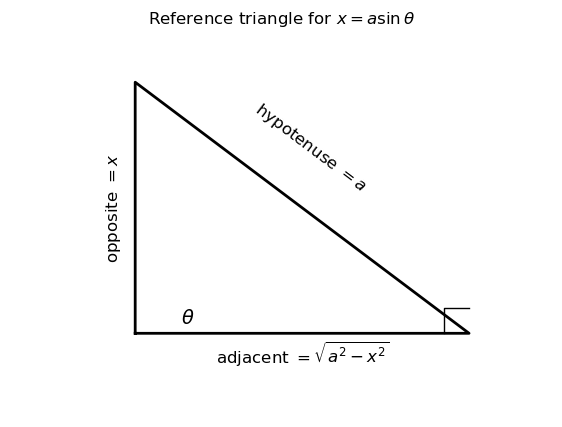

In [3]:
fig, ax = plt.subplots(figsize=(7, 5))

# right triangle: opposite = x, hypotenuse = a, adjacent = sqrt(a^2 - x^2)
ax.plot([0, 4, 0, 0], [0, 0, 3, 0], 'k-', linewidth=2)
# right-angle marker
ax.plot([3.7, 3.7, 4.0], [0, 0.3, 0.3], 'k-', linewidth=1)

ax.text(2.0, -0.35, r"adjacent $= \sqrt{a^2 - x^2}$", ha='center', fontsize=12)
ax.text(2.1, 1.7, r"hypotenuse $= a$", ha='center', fontsize=12, rotation=-37)
ax.text(-0.15, 1.5, r"opposite $= x$", ha='right', va='center', fontsize=12, rotation=90)
ax.text(0.55, 0.12, r"$\theta$", fontsize=14)

ax.set_title(r"Reference triangle for $x = a\sin\theta$")
ax.set_xlim(-1.5, 5); ax.set_ylim(-1, 3.6)
ax.axis('off')
plt.show()

## 5. The Tangent Case: $\sqrt{a^2 + x^2}$

Substitute $x = a\tan\theta$, so $dx = a\sec^2\theta\,d\theta$. Then

$$
\sqrt{a^2 + x^2} = \sqrt{a^2 + a^2\tan^2\theta} = a\sqrt{1 + \tan^2\theta} = a\sqrt{\sec^2\theta} = a\sec\theta.
$$

### Worked example

$$
I = \int \frac{1}{\sqrt{x^2 + 4}}\,dx.
$$

Here $a = 2$, so $x = 2\tan\theta$, $dx = 2\sec^2\theta\,d\theta$, and $\sqrt{x^2 + 4} = 2\sec\theta$:

$$
I = \int \frac{2\sec^2\theta}{2\sec\theta}\,d\theta = \int \sec\theta\,d\theta = \ln|\sec\theta + \tan\theta| + C.
$$

Here we reuse $\displaystyle\int \sec\theta\,d\theta = \ln|\sec\theta + \tan\theta| + C$ from the $u$-substitution notebook!

**Substitute back** with the triangle (opposite $= x$, adjacent $= 2$, hypotenuse $= \sqrt{x^2+4}$): $\sec\theta = \dfrac{\sqrt{x^2+4}}{2}$ and $\tan\theta = \dfrac{x}{2}$, so

$$
I = \ln\left|\frac{\sqrt{x^2+4}}{2} + \frac{x}{2}\right| + C = \ln\left|x + \sqrt{x^2+4}\right| + C,
$$

where the $\ln 2$ is absorbed into the constant. Therefore:

$$
\boxed{\;\int \frac{1}{\sqrt{x^2 + 4}}\,dx = \ln\left|x + \sqrt{x^2 + 4}\right| + C\;}
$$

In [4]:
I = sp.integrate(1/sp.sqrt(x**2 + 4), x)
print("SymPy:", I, "+ C")
# SymPy may use asinh; confirm it matches ln|x + sqrt(x^2+4)| via the derivative
F = sp.log(x + sp.sqrt(x**2 + 4))
print("d/dx ln|x + sqrt(x^2+4)| =", sp.simplify(sp.diff(F, x)))
print("original integrand        =", sp.simplify(1/sp.sqrt(x**2 + 4)))

SymPy: asinh(x/2) + C
d/dx ln|x + sqrt(x^2+4)| = 1/sqrt(x**2 + 4)
original integrand        = 1/sqrt(x**2 + 4)


## 6. The Secant Case: $\sqrt{x^2 - a^2}$

Substitute $x = a\sec\theta$, so $dx = a\sec\theta\tan\theta\,d\theta$. Then

$$
\sqrt{x^2 - a^2} = \sqrt{a^2\sec^2\theta - a^2} = a\sqrt{\sec^2\theta - 1} = a\sqrt{\tan^2\theta} = a\tan\theta.
$$

### Worked example

$$
I = \int \frac{1}{\sqrt{x^2 - 1}}\,dx.
$$

Here $a = 1$, so $x = \sec\theta$, $dx = \sec\theta\tan\theta\,d\theta$, and $\sqrt{x^2 - 1} = \tan\theta$:

$$
I = \int \frac{\sec\theta\tan\theta}{\tan\theta}\,d\theta = \int \sec\theta\,d\theta = \ln|\sec\theta + \tan\theta| + C.
$$

**Substitute back** (triangle: hypotenuse $= x$, adjacent $= 1$, opposite $= \sqrt{x^2-1}$): $\sec\theta = x$ and $\tan\theta = \sqrt{x^2-1}$, so

$$
\boxed{\;\int \frac{1}{\sqrt{x^2 - 1}}\,dx = \ln\left|x + \sqrt{x^2 - 1}\right| + C\;}
$$

In [5]:
x_big = sp.symbols('x', positive=True)
I = sp.integrate(1/sp.sqrt(x_big**2 - 1), x_big)
print("SymPy:", I, "+ C")
F = sp.log(x_big + sp.sqrt(x_big**2 - 1))
print("d/dx ln|x + sqrt(x^2-1)| =", sp.simplify(sp.diff(F, x_big)))

SymPy: log(x + sqrt(x**2 - 1)) + C
d/dx ln|x + sqrt(x^2-1)| = 1/sqrt(x**2 - 1)


## 7. A Geometric Check: Area of a Semicircle

The sine substitution gives a satisfying geometric result. The curve $y = \sqrt{a^2 - x^2}$ is the **upper half of a circle** of radius $a$. Integrating it from $-a$ to $a$ must give half the circle's area, $\tfrac{1}{2}\pi a^2$.

Using $\displaystyle\int \sqrt{a^2 - x^2}\,dx = \frac{x}{2}\sqrt{a^2 - x^2} + \frac{a^2}{2}\arcsin\!\left(\frac{x}{a}\right) + C$, let us verify this for $a = 3$.

integral of sqrt(9 - x^2) from -3 to 3 = 9*pi/2
half the area of a circle of radius 3  = 9*pi/2


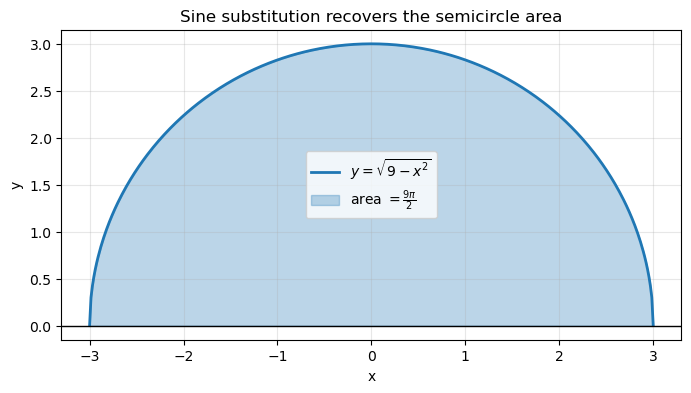

In [6]:
area = sp.integrate(sp.sqrt(9 - x**2), (x, -3, 3))
print("integral of sqrt(9 - x^2) from -3 to 3 =", area)
print("half the area of a circle of radius 3  =", sp.Rational(1, 2)*sp.pi*3**2)

xv = np.linspace(-3, 3, 400)
yv = np.sqrt(9 - xv**2)
plt.figure(figsize=(8, 4.5))
plt.plot(xv, yv, color='tab:blue', linewidth=2, label=r"$y = \sqrt{9 - x^2}$")
plt.fill_between(xv, yv, alpha=0.3, color='tab:blue', label=r"area $= \frac{9\pi}{2}$")
plt.title("Sine substitution recovers the semicircle area")
plt.xlabel("x"); plt.ylabel("y")
plt.axhline(0, lw=1, color='black')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3); plt.legend()
plt.show()

## 8. Summary of the Method

1. **Match** the square root to one of the three forms and read off $a$.
2. **Substitute** $x = a\sin\theta$, $a\tan\theta$, or $a\sec\theta$, and compute $dx$.
3. **Simplify** the root using the matching Pythagorean identity — it collapses to a single trig function.
4. **Integrate** the resulting trig integral.
5. **Substitute back** to $x$ using a **reference triangle**.

| Form | Substitution | Root becomes |
|------|--------------|--------------|
| $\sqrt{a^2 - x^2}$ | $x = a\sin\theta$ | $a\cos\theta$ |
| $\sqrt{a^2 + x^2}$ | $x = a\tan\theta$ | $a\sec\theta$ |
| $\sqrt{x^2 - a^2}$ | $x = a\sec\theta$ | $a\tan\theta$ |

## 9. Exercises

### Basic

1. Which substitution fits $\displaystyle\int \frac{1}{\sqrt{25 - x^2}}\,dx$? Then evaluate it.
2. Evaluate $\displaystyle\int \frac{1}{x^2 + 9}\,dx$ using $x = 3\tan\theta$.

### Intermediate

3. Evaluate $\displaystyle\int \frac{1}{\sqrt{x^2 + 16}}\,dx$.
4. Evaluate $\displaystyle\int \sqrt{4 - x^2}\,dx$.

### Advanced

5. Evaluate the definite integral $\displaystyle\int_0^{2} \sqrt{4 - x^2}\,dx$ and interpret it geometrically.
6. Evaluate $\displaystyle\int \frac{1}{x^2\sqrt{x^2 - 1}}\,dx$ using $x = \sec\theta$ (hint: the integral becomes $\int \cos\theta\,d\theta$).

## 10. Solutions / Checks

**1.** $\sqrt{25 - x^2}$ matches the sine case with $a = 5$: $x = 5\sin\theta$ gives $\displaystyle\int d\theta = \arcsin\!\left(\frac{x}{5}\right) + C$.

**2.** $x = 3\tan\theta$, $dx = 3\sec^2\theta\,d\theta$, $x^2 + 9 = 9\sec^2\theta$: $\displaystyle\int \frac{3\sec^2\theta}{9\sec^2\theta}\,d\theta = \frac{1}{3}\int d\theta = \frac{1}{3}\arctan\!\left(\frac{x}{3}\right) + C$.

**3.** Tangent case, $a = 4$: $\displaystyle\int \sec\theta\,d\theta = \ln\left|x + \sqrt{x^2 + 16}\right| + C$.

**4.** Sine case, $a = 2$: $\displaystyle\int \sqrt{4 - x^2}\,dx = \frac{x}{2}\sqrt{4 - x^2} + 2\arcsin\!\left(\frac{x}{2}\right) + C$.

**5.** $\displaystyle\int_0^2 \sqrt{4 - x^2}\,dx = \pi$ — the area of a quarter-circle of radius $2$, namely $\tfrac{1}{4}\pi(2)^2 = \pi$.

**6.** $x = \sec\theta$ turns the integral into $\displaystyle\int \cos\theta\,d\theta = \sin\theta + C = \frac{\sqrt{x^2 - 1}}{x} + C$.

Run the cell below to verify these symbolically.

In [7]:
x = sp.symbols('x', real=True)
xp = sp.symbols('x', positive=True)

print("1.", sp.integrate(1/sp.sqrt(25 - x**2), x), "+ C")
print("2.", sp.integrate(1/(x**2 + 9), x), "+ C")
print("3.", sp.simplify(sp.integrate(1/sp.sqrt(x**2 + 16), x)), "+ C")
print("4.", sp.simplify(sp.integrate(sp.sqrt(4 - x**2), x)), "+ C")
print("5.", sp.integrate(sp.sqrt(4 - x**2), (x, 0, 2)))
print("6.", sp.simplify(sp.integrate(1/(xp**2*sp.sqrt(xp**2 - 1)), xp)), "+ C")

1. asin(x/5) + C
2. atan(x/3)/3 + C
3. asinh(x/4) + C
4. x*sqrt(4 - x**2)/2 + 2*asin(x/2) + C
5. pi


6. Piecewise((sqrt(x**2 - 1)/x, x**2 > 1), (I*sqrt(1 - x**2)/x, True)) + C


## 11. Conclusion

In this topic we learned **trigonometric substitution**, a method for integrals containing the square root of a quadratic:

- $\sqrt{a^2 - x^2}$ &nbsp;→&nbsp; $x = a\sin\theta$ &nbsp;→&nbsp; root becomes $a\cos\theta$;
- $\sqrt{a^2 + x^2}$ &nbsp;→&nbsp; $x = a\tan\theta$ &nbsp;→&nbsp; root becomes $a\sec\theta$;
- $\sqrt{x^2 - a^2}$ &nbsp;→&nbsp; $x = a\sec\theta$ &nbsp;→&nbsp; root becomes $a\tan\theta$.

Each substitution uses a **Pythagorean identity** to remove the root, and a **reference triangle** to substitute back. Two of the cases lead straight to the secant integral $\int \sec\theta\,d\theta = \ln|\sec\theta + \tan\theta| + C$ derived earlier.

Key lesson:

$$
\text{a square root of a quadratic} \;\xrightarrow{\text{trig substitution}}\; \text{a trig integral you already know.}
$$